In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.utils import to_categorical
import random
import seaborn as sns

# These are the main arrhythmia types in MIT-BIH
# N=Normal, V=PVC, A=Atrial Premature, L=Left Bundle Branch Block, R=Right Bundle Branch Block
TARGET_CLASSES = ['N', 'V', 'A', 'L', 'R']

def load_beats_multiclass(record_id):
    try:
        record = wfdb.rdrecord(f'mitdb/{record_id}')
        annotation = wfdb.rdann(f'mitdb/{record_id}', 'atr')
    except:
        return [], []

    signal = record.p_signal[:, 0]
    beat_samples = annotation.sample
    labels = annotation.symbol
    beats, classes = [], []

    for i, sym in enumerate(labels):
        if sym not in TARGET_CLASSES:
            continue
        r = beat_samples[i]
        if r - 50 < 0 or r + 50 > len(signal):
            continue
        beat = signal[r - 50:r + 50]
        beats.append(beat)
        classes.append(sym)

    return beats, classes

# Load all records
all_beats = {c: [] for c in TARGET_CLASSES}
for pid in range(100, 235):
    beats, labels = load_beats_multiclass(str(pid))
    for b, l in zip(beats, labels):
        if l in all_beats:
            all_beats[l].append(b)

for cls, beats in all_beats.items():
    print(f"{cls}: {len(beats)} beats")

N: 75045 beats
V: 7129 beats
A: 2546 beats
L: 8075 beats
R: 7259 beats


In [3]:
# Balance classes to the smallest class size
min_len = min(len(v) for v in all_beats.values())
print(f"Balancing all classes to {min_len} beats each")

X, y_raw = [], []
for cls in TARGET_CLASSES:
    sampled = random.sample(all_beats[cls], min_len)
    X.extend(sampled)
    y_raw.extend([cls] * min_len)

X = np.array(X)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
y_cat = to_categorical(y, len(TARGET_CLASSES))

print(f"Classes: {le.classes_}")
print(f"Total samples: {len(X)}")

# Shuffle
idx = np.random.permutation(len(X))
X, y, y_cat = X[idx], y[idx], y_cat[idx]

# Train/test split
X_train, X_test, y_train, y_test, y_train_cat, y_test_cat = train_test_split(
    X, y, y_cat, test_size=0.2, stratify=y
)

# Reshape for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Build improved CNN
model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(100, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(TARGET_CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Balancing all classes to 2546 beats each
Classes: ['A' 'L' 'N' 'R' 'V']
Total samples: 12730
Train: 10184, Test: 2546


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725,253 (2.77 MB)

 Trainable params: 724,805 (2.76 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
# Train the multiclass CNN
history = model.fit(
    X_train_cnn, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7913 - loss: 0.6265 - val_accuracy: 0.4659 - val_loss: 1.4451
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8765 - loss: 0.3608 - val_accuracy: 0.8841 - val_loss: 0.3287
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9013 - loss: 0.2956 - val_accuracy: 0.9175 - val_loss: 0.2392
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9084 - loss: 0.2651 - val_accuracy: 0.9219 - val_loss: 0.2427
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9196 - loss: 0.2391 - val_accuracy: 0.9107 - val_loss: 0.2379
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9250 - loss: 0.2081 - val_accuracy: 0.9273 - val_loss: 0.2056
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9276 - loss: 0.2008 - val_accuracy: 0.9205 - val_loss: 0.2464
Epoch 8/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9348 - loss: 0.1846 - val_accuracy: 0.

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Multiclass CNN Classification Report:

              precision    recall  f1-score   support

           A       0.88      0.91      0.89       510
           L       0.99      1.00      0.99       509
           N       0.92      0.89      0.91       509
           R       0.98      0.96      0.97       509
           V       0.98      0.98      0.98       509

    accuracy                           0.95      2546
   macro avg       0.95      0.95      0.95      2546
weighted avg       0.95      0.95      0.95      2546



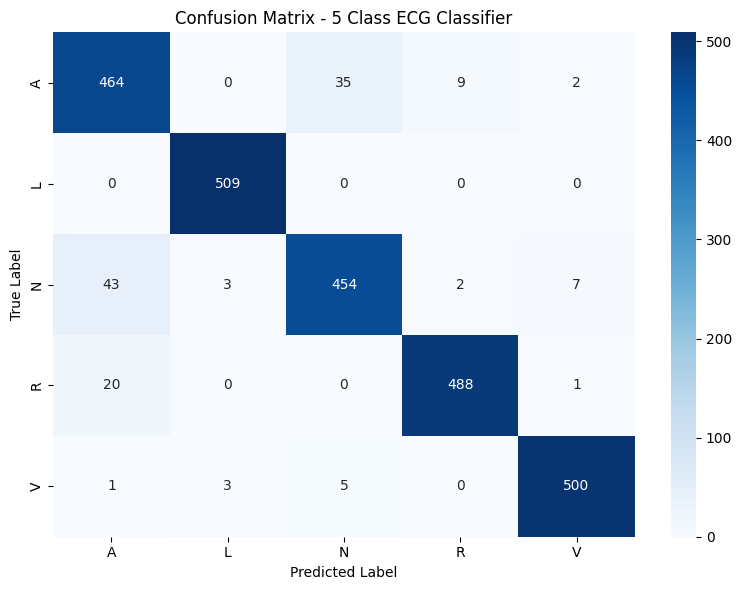


Model and label encoder saved! ✅


In [5]:
# Evaluate
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Multiclass CNN Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - 5 Class ECG Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../results/multiclass_confusion_matrix.png')
plt.show()

# Save model
model.save('../models/ecg_multiclass_cnn.keras')
import joblib
joblib.dump(le, '../models/label_encoder.pkl')
print("\nModel and label encoder saved! ✅")

In [1]:
import wfdb
import numpy as np

# Export a real ECG record as a CSV for testing
record = wfdb.rdrecord('mitdb/100')
signal = record.p_signal[:, 0].astype(np.float32)
np.savetxt('../data/test_ecg.csv', signal, delimiter=',')
print(f"Test ECG saved! {len(signal)} samples")

Test ECG saved! 650000 samples
